In [6]:
# from read_multi_ase_simple import *
from extract_simple import *

import torch
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt

# from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool, Sequential
from torch_geometric.loader import DataLoader
from tqdm import tqdm

In [7]:
my_path = '../../data'
MAX_MOLS = 100

files_list = find_files(my_path)

# Process files from list and extract specified number of molecules and type
dataset = process_file(files_list, molecule_type = 'biomolecules', max_molecules = MAX_MOLS)

# Get final dataset for use with PyG 
torch_data = get_data(dataset)

final_dataset = split_data(torch_data, 0.8)

Processed 100 atoms


In [8]:
train_dataset = final_dataset[0]
val_dataset = final_dataset[1]

print(len(train_dataset), len(val_dataset))

80 20


In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [10]:
# inherit from nn.Module 
class SimpleGNN(nn.Module):
    def __init__(self, num_node_features=1, hidden_channels=64):
        # call constructor from parent class 
        super().__init__()

        self.simpleGNN = Sequential('x, edge_index, batch', [
            # CONVOLUTION LAYERS: learn molecular represenation 
            # layer 1: directly bonded atoms
            (GCNConv(num_node_features, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 2: local chemical environment (i.e., funct groups)
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),
            # layer 3: adds global context
            (GCNConv(hidden_channels, hidden_channels), 'x, edge_index -> x'),
            nn.ReLU(),

            # POOLING: down-sample/reduce dimensions 
            (global_mean_pool, 'x, batch -> x'),

            # LINEAR LAYERS: turn into actual predictions 
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)])


    def forward(self, x, edge_index, batch):
        return self.simpleGNN(x, edge_index, batch).reshape(-1)

In [11]:
# code taken from Module 9 bloodmnist_pytroch.ipynb demo 

def train_model(model, train_loader, val_loader, loss_fn, optimizer,
                epochs=10, print_every=1, device='cpu'):

    # for storing losses for plotting 
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

    model = model.to(device) # move to device (cpu/gpu/mps as specified)

    for epoch in tqdm(range(epochs), desc='Training'):
        # TRAINING
        model.train()
        
        # initialize losses to 0
        epoch_train_loss = 0.0
        epoch_train_mae = 0.0

        # iterate thru each batch 
        for batch in train_loader:
            batch = batch.to(device) # move to specified device 

            # inputs [x, edge_index, batch]
            predictions = model(batch.x, batch.edge_index, batch.batch)
            targets = batch.y.reshape(-1).float() # reshape 

            # compare to target and calculate loss 
            loss = loss_fn(predictions, targets)

            optimizer.zero_grad() # zero out grads
            loss.backward() # back-prop 
            optimizer.step() # update/adjust 

            epoch_train_loss += loss.item() # add to running loss 
            epoch_train_mae += torch.mean(torch.abs(predictions - targets)).item() 

        # calculate avg losses 
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_mae = epoch_train_mae / len(train_loader)

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_mae = 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)

                predictions = model(batch.x, batch.edge_index, batch.batch)
                targets = batch.y.reshape(-1).float()

                loss = loss_fn(predictions, targets)

                epoch_val_loss += loss.item()
                epoch_val_mae += torch.mean(torch.abs(predictions - targets)).item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_mae = epoch_val_mae / len(val_loader)

        # Record
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_mae'].append(avg_train_mae)
        history['val_mae'].append(avg_val_mae)

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f} | "
                f"Train MAE: {avg_train_mae:.4f} | "
                f"Val MAE: {avg_val_mae:.4f}"
            )

    return history


In [12]:
def plot_losses(history):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss',
             linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
# initialize model 
simpleGNN = SimpleGNN()
print(simpleGNN)

SimpleGNN(
  (simpleGNN): Sequential(
    (0) - GCNConv(1, 64): x, edge_index -> x
    (1) - ReLU(): x -> x
    (2) - GCNConv(64, 64): x, edge_index -> x
    (3) - ReLU(): x -> x
    (4) - GCNConv(64, 64): x, edge_index -> x
    (5) - ReLU(): x -> x
    (6) - <function global_mean_pool at 0x166391900>: x, batch -> x
    (7) - Linear(in_features=64, out_features=64, bias=True): x -> x
    (8) - ReLU(): x -> x
    (9) - Linear(in_features=64, out_features=64, bias=True): x -> x
    (10) - ReLU(): x -> x
    (11) - Linear(in_features=64, out_features=1, bias=True): x -> x
  )
)


In [14]:
my_lr = 1e-3
my_loss_fn = nn.MSELoss()
my_optimizer = optim.Adam(simpleGNN.parameters(), lr=my_lr)

In [15]:
simpleGNN.parameters()

<generator object Module.parameters at 0x169afbed0>

In [16]:
history = train_model(
    model = simpleGNN, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    loss_fn = my_loss_fn,
    optimizer = my_optimizer,
    epochs = 50,
    print_every = 5
)

Training:  16%|█▌        | 8/50 [00:00<00:02, 19.68it/s]

Epoch   5/50 | Train Loss: 65.7957 | Val Loss: 67.2389 | Train MAE: 7.8097 | Val MAE: 8.0096


Training:  26%|██▌       | 13/50 [00:00<00:02, 18.30it/s]

Epoch  10/50 | Train Loss: 30.5036 | Val Loss: 21.9912 | Train MAE: 5.0259 | Val MAE: 4.2910


Training:  38%|███▊      | 19/50 [00:00<00:01, 20.90it/s]

...

Epoch  30/50 | Train Loss: 8.2532 | Val Loss: 6.2637 | Train MAE: 2.3614 | Val MAE: 2.1080
Epoch  35/50 | Train Loss: 7.6839 | Val Loss: 6.2179 | Train MAE: 2.2803 | Val MAE: 2.1001


Training:  86%|████████▌ | 43/50 [00:02<00:00, 24.80it/s]

Epoch  40/50 | Train Loss: 7.2818 | Val Loss: 6.1952 | Train MAE: 2.2258 | Val MAE: 2.0984
Epoch  45/50 | Train Loss: 7.5094 | Val Loss: 6.1105 | Train MAE: 2.2777 | Val MAE: 2.0792


Training: 100%|██████████| 50/50 [00:02<00:00, 21.71it/s]

Epoch  50/50 | Train Loss: 7.6993 | Val Loss: 6.1933 | Train MAE: 2.2981 | Val MAE: 2.1126


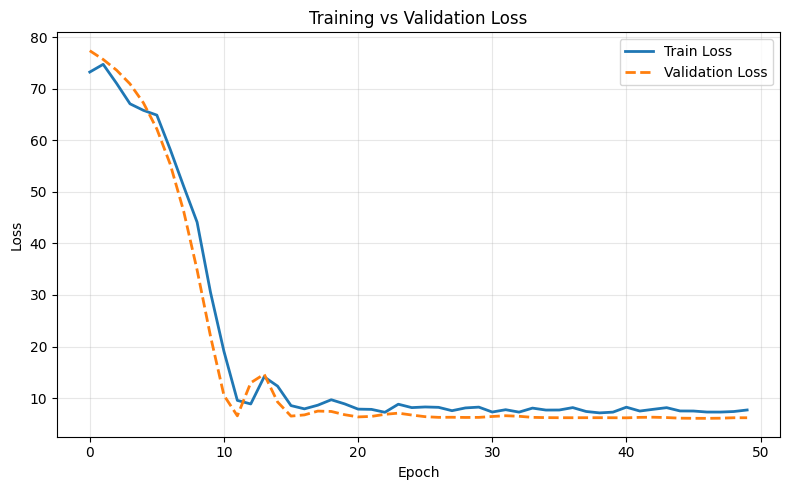

In [17]:
plot_losses(history)